In [11]:
#Importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [12]:
#Importing the dataset and print the outputs 
df = pd.read_csv('spotify_tracks.csv')
print(df.head())
df = df.dropna()


   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   


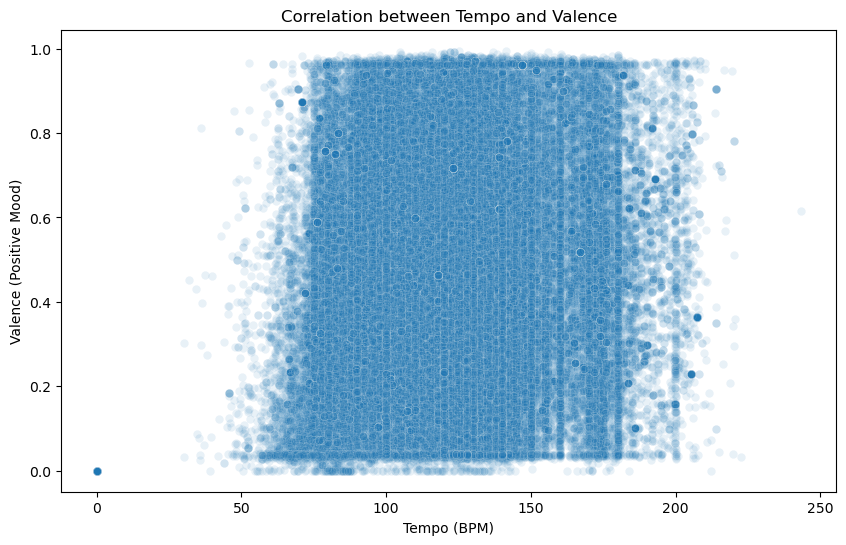

In [13]:
#Check the correlation between tempo(BPM) and emotional valence 
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tempo', y='valence', alpha=0.1)
plt.title('Correlation between Tempo and Valence')
plt.xlabel('Tempo (BPM)')
plt.ylabel('Valence (Positive Mood)')
plt.show()



From the statistical analysis of the scatter plot between tempo (BPM) and emotional valence, we observe a uniform distribution of the data with no apparent linear or nonlinear correlation. The dense clustering of data points in the center is due to the large sample size (overplotting). This finding suggests that a song’s tempo (BPM) is not a determining factor in whether the song’s emotional valence will be positive or negative, which justifies the use of more complex algorithms (such as K-Means) to identify multidimensional patterns.

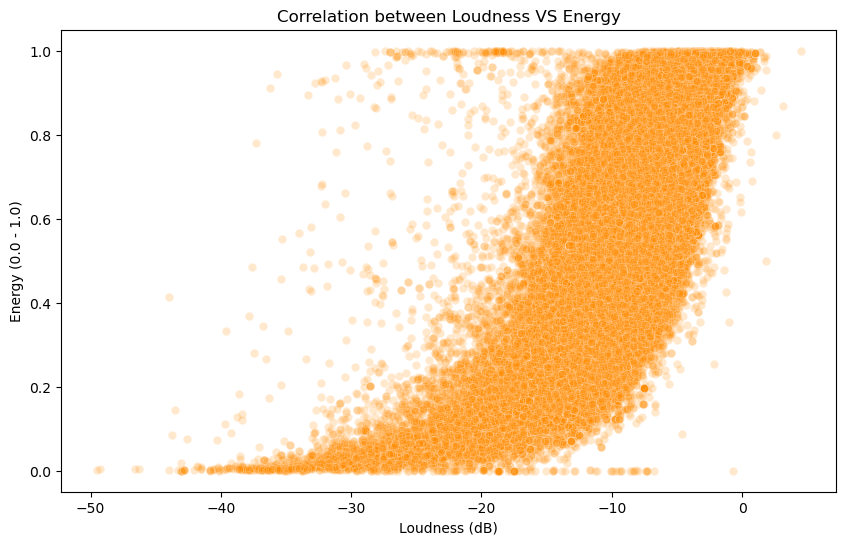

In [14]:

#Check the correlation between loudness and energy as well
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='loudness', y='energy', alpha=0.2, color='darkorange')

plt.title('Correlation between Loudness VS Energy')
plt.xlabel('Loudness (dB)')
plt.ylabel('Energy (0.0 - 1.0)')
plt.show()

The statistical analysis of the scatter plot between Loudness and Energy reveals a strong, nonlinear positive correlation. The use of alpha blending reveals a clear upward curve: as the sound intensity increases (approaching 0 dB on the X-axis), the track’s energy increases exponentially toward 1.0.

Furthermore, we observe that at low volume levels, the variation is very small (the data are “compressed” at low levels), while as the volume increases, the energy exhibits greater variability. This finding confirms the musical theory that loudness is one of the most fundamental structural factors determining the perceived energy of a song



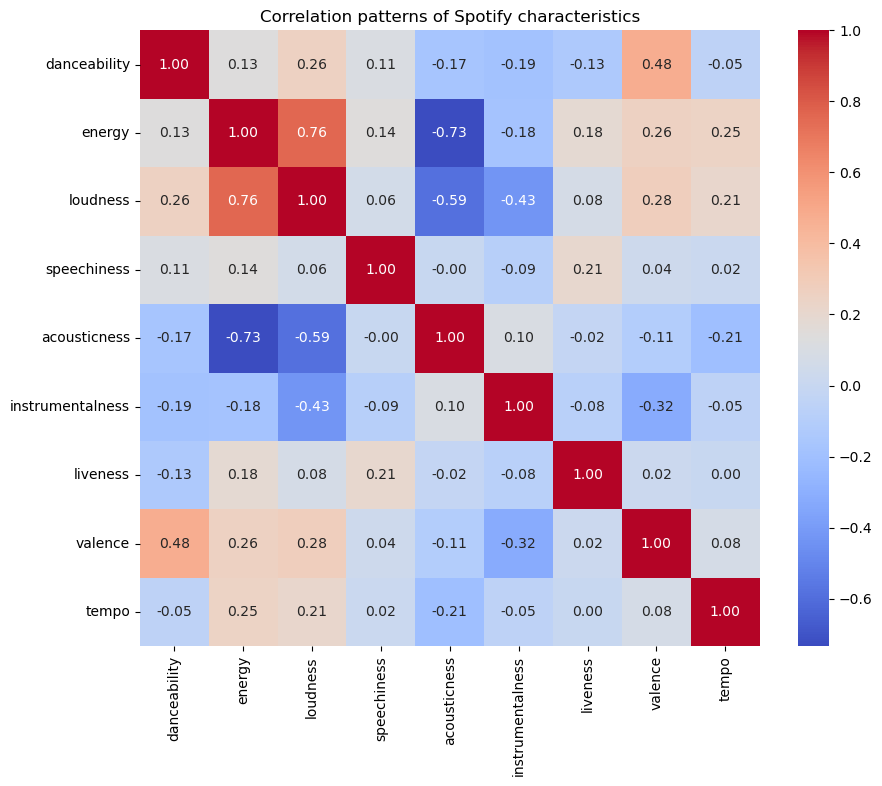

In [15]:
#Check which characteristics correlate with each other 
numeric_cols = df[['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']]
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation patterns of Spotify characteristics')
plt.show()



To guide feature selection prior to training the K-Means algorithm, a correlation matrix was created using Pearson correlation. The main findings include:
- A high linear correlation (0.76) between Energy and Loudness, indicating that sound pressure is directly linked to the perception of energy.

- A strong inverse (negative) correlation (-0.73) between Energy and Acousticness, which clearly distinguishes purely acoustic tracks from electro/pop/rock genres.

- A moderate positive correlation (0.48) between Danceability and Valence, indicating that a strong danceable rhythm is often associated with a positive emotional charge.

These interdependencies were taken into account during the standard scaling of the data so that the K-Means algorithm could correctly cluster the tracks into playlists without being misled by variables that capture the same information.

In [16]:
#Machine Learn(ML) algorithm K-Means to analyze the characteristic of the songs and divide them in categories
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = df[['danceability', 'energy', 'valence', 'tempo']]



In [17]:
# Scaling of the data 
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)



In [18]:
# Learn to the algorithm to make 4 groups Playlists
kmeans = KMeans(n_clusters=4, random_state=42)
df['playlist_cluster'] = kmeans.fit_predict(features_scaled)

print("Songs in Playlist 0:")
print(df[df['playlist_cluster'] == 0][['track_name', 'artists']].head())



Songs in Playlist 0:
                                           track_name           artists
32        All I Want For Christmas Is A Real Good Tan  Chord Overstreet
40                                          The Haves      Eddie Vedder
44  Speak Your Mind (From the Netflix Series "We T...    Brandi Carlile
51                                            透明だった世界     Motohiro Hata
52                                             Pieces      Andrew Belle


In [ ]:
# Calculation of the mean of the characteristics for each cluster
cluster_profiles = df.groupby('playlist_cluster')[['danceability', 'energy', 'valence', 'tempo']].mean()

print("--- 4 Playlists Characteristics ---")
print(cluster_profiles)